### [주제 : Bream과 Smelt 분류 모델 ]
- 데  이 터 : fish.csv 
- 특성/피쳐 : Height, Weight, Length
- 타겟/라벨 : Species => Bream, Smelt
- 학습 종류 : 지도학습 - 분류
- 학습 방법 : KNN - 최근접이웃 : 유유상종

- **[0] 모듈 로딩**

In [20]:
## 데이터 처리 관련
import pandas as pd
import numpy as np

## 시각화 관련
import matplotlib.pyplot as plt 
import koreanize_matplotlib 

## 머신러닝 관련
## -> 데이터셋
from sklearn.model_selection import train_test_split
## -> 교차검증 + 튜닝
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV 
## -> 모델
from sklearn.neighbors import KNeighborsClassifier 

- **[1] 데이터 준비**
    * 데이터 파일/폴더 설정
    * 데이터 로딩
    * 데이터 기본 정보 확인 : info()+head()/tail(), describe(include='all')

In [21]:
##=> 데이터 선정
DATA_FILE = '../Data/Numbers/fish.csv' 

In [22]:
##=> 데이터 로딩 : 첫번째 줄 컬럼명, 쉼표(,) 구분자
##=> 행   : 품종 Bream, Smelt인 행
##=> 컬럼 : 'Species','Weight','Length','Height'
fishDF = pd.read_csv(DATA_FILE, 
                     usecols=['Species','Weight','Length','Height'],
                     skiprows=range(36, 146))


In [23]:
##=> 데이터 기본 정보
##=> 컬럼에 결측치, 타입 체크 --> 자료형변환 여부 
fishDF.info() 
display(fishDF.head(3))

##=> 컬럼별 데이터 분포 
##=> 품  종 컬럼 : 불균형 데이터 -> Bream : Smelt = 35 : 14
##=> 나머지 컬럼 : 평균<중간값 -> 오른쪽으로 약간 치우쳐 있음. 작은생선/큰생선 
print("="*60)
display( fishDF.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  49 non-null     str    
 1   Weight   49 non-null     float64
 2   Length   49 non-null     float64
 3   Height   49 non-null     float64
dtypes: float64(3), str(1)
memory usage: 1.7 KB


,Species,Weight,Length,Height
0,Bream,242.0,25.4,11.5200
1,Bream,290.0,26.3,12.4800
2,Bream,340.0,26.5,12.3778


,Species,Weight,Length,Height
count,49,49.000000,49.000000,49.000000
unique,2,NaN,NaN,NaN
top,Bream,NaN,NaN,NaN
freq,35,NaN,NaN,NaN
mean,NaN,444.500000,27.055102,11.476400
std,NaN,328.143233,10.242804,6.150976
min,NaN,6.700000,9.800000,1.728400
25%,NaN,19.700000,14.300000,2.872800
50%,NaN,500.000000,31.000000,14.179500
75%,NaN,700.000000,34.500000,15.633000


- **[2]피쳐로 타겟 분류 가능 여부 체크**
    * 시각화 확인

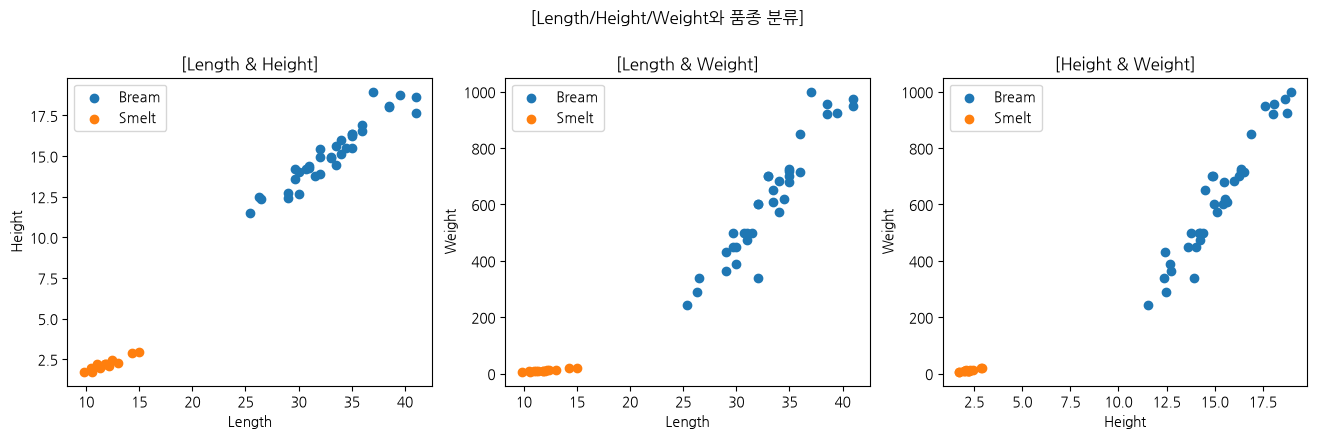

In [24]:
## 길이, 높이 => 2개 품종 식별 체크 | 길이, 무게 => 2개 품종 식별 체크 | 높이, 무게 =>  2개 품종 식별 체크
## - 1행 3열, 품종별 다른 색상, 산점도
cols = [['Length','Height'], ['Length','Weight'], ['Height','Weight']]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (col1, col2) in zip(axes, cols):
    breamDF = fishDF[fishDF['Species'] == 'Bream']
    smeltDF = fishDF[fishDF['Species'] == 'Smelt']
    ax.scatter(breamDF[col1], breamDF[col2], label='Bream')
    ax.scatter(smeltDF[col1], smeltDF[col2], label='Smelt')

    ax.set_title(f'[{col1} & {col2}]')
    ax.set_xlabel(col1)
    ax.set_ylabel(col2)
    ax.legend()
plt.suptitle('[Length/Height/Weight와 품종 분류]', y=1.05)

plt.show()

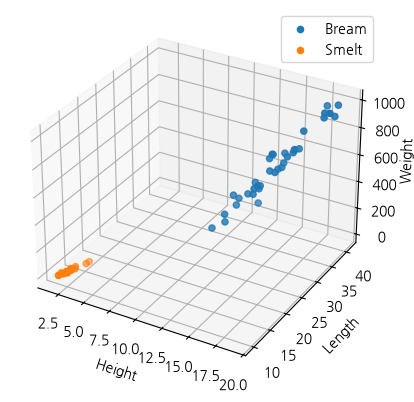

In [25]:
## => 3D 시각화 :  projection='3d'설정
#fig= plt.figure(figsize=(10, 6), edgecolor='black')
ax = plt.axes(projection='3d')

ax.scatter(breamDF['Height'], breamDF['Length'], breamDF['Weight'], label='Bream')
ax.scatter(smeltDF['Height'], smeltDF['Length'], smeltDF['Weight'], label='Smelt')
ax.set_xlabel('Height')
ax.set_ylabel('Length')
ax.set_zlabel('Weight', labelpad=0)

plt.subplots_adjust(left=0.05, right=0.65)
plt.legend()
plt.show()

- **[3]데이터셋 준비**
    * 피쳐와 타겟 분리
    * 학습용과 테스트용 분리

In [26]:
##=> 피쳐와 타겟 분리
featureDF = fishDF[fishDF.columns[1:]]
targetSR  = fishDF[fishDF.columns[0]]

print(f'피쳐 :{featureDF.shape} | 타겟 : {targetSR.shape}')

피쳐 :(49, 3) | 타겟 : (49,)


In [27]:
##=> 학습용, 테스트용 분리 : 분류 모델로 클래스/타겟 비율 유지
x_train, x_test, y_train, y_test = train_test_split(featureDF, 
                                                    targetSR,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=targetSR)

In [28]:
## 확인
print('[학습용]-------')
print(f'x_train: {x_train.shape}, y_train: {y_train.shape}')
print(f'y_train: {((y_test.value_counts()/y_test.shape[0]).round(1)).to_list()}')

print('[테스트용]-------')
print(f'x_test: {x_test.shape}, y_train: {y_test.shape}')
print(f'y_test: {(y_test.value_counts()/y_test.shape[0]).to_list()}')

[학습용]-------
x_train: (39, 3), y_train: (39,)
y_train: [0.7, 0.3]
[테스트용]-------
x_test: (10, 3), y_train: (10,)
y_test: [0.7, 0.3]


- **[4]학습**

In [29]:
## 파라미터 
params = {'n_neighbors' : range(3,30,2)}

model = KNeighborsClassifier()
scv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gsModel = GridSearchCV(model, param_grid=params, cv=scv, return_train_score=True)

In [30]:
## => 교차검증 학습 진행
gsModel.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(3, 30, 2)}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See 

In [31]:
## => 결과 분석
sel_cols = ['rank_test_score',  'param_n_neighbors', 
            'mean_test_score',  'std_test_score', 
            'mean_train_score', 'std_train_score']

cvDF = pd.DataFrame(gsModel.cv_results_, columns=sel_cols)

In [32]:
cvDF['mean_test_score'].min(), cvDF['mean_test_score'].max()

(np.float64(0.7178571428571429), np.float64(1.0))

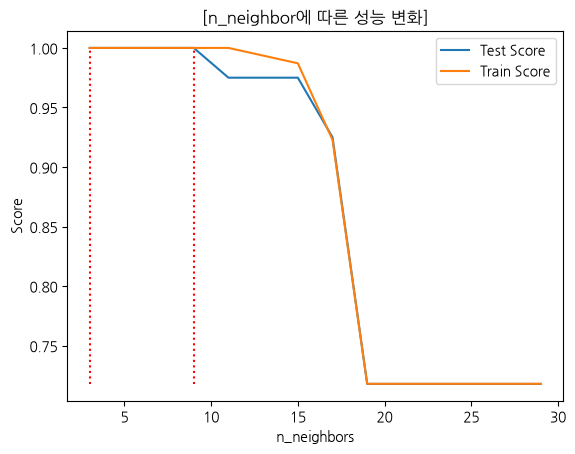

In [33]:
## --------------------------------------------------------------
##=> n_neighbor값 변화에 따른 훈련 점수/테스트(검증) 점수 변화 시각화
## --------------------------------------------------------------
sortDF = cvDF.sort_values(by=['param_n_neighbors'])

##- 테스트/검증 점수,  훈련 점수 
plt.plot(sortDF['param_n_neighbors'], sortDF['mean_test_score'], label='Test Score')
plt.plot(sortDF['param_n_neighbors'], sortDF['mean_train_score'], label='Train Score')

##- n_neighbors 구간
plt.vlines(3, cvDF['mean_test_score'].min(), cvDF['mean_test_score'].max(), colors='red', linestyles='dotted')
plt.vlines(9, cvDF['mean_test_score'].min(), cvDF['mean_test_score'].max(), colors='red', linestyles='dotted')


plt.xlabel('n_neighbors')
plt.ylabel('Score')
plt.title('[n_neighbor에 따른 성능 변화]')
plt.legend()
plt.show()

In [34]:
## => 성능 확인
print(f'최고 K   : {gsModel.best_params_}')
print(f'최고 성능 : {gsModel.best_score_}')

## => 최적의 파라미터 설정 + 재학습된 모델 인스턴스
bestModel = gsModel.best_estimator_

최고 K   : {'n_neighbors': 3}
최고 성능 : 1.0


- **[5] 예측**
    * 테스트 데이터셋 예측
    * 실제 데이터셋 예측

In [35]:
## -------------------------------------------------------
## => 테스트 데이터셋 예측
## -------------------------------------------------------
y_pre = bestModel.predict(x_test)

## 정답과 비교 
compareDF = pd.DataFrame(np.vstack([y_test, y_pre]), index=['정답','예측']).T
compareDF['결과'] = compareDF['정답'] == compareDF['예측']

## 정답, 오답 계산
correct, incorrect = compareDF['결과'].sum(),  compareDF.shape[0] - compareDF['결과'].sum()

print(f'[결과] 정답 수 : {correct}개, 오답 수 : {incorrect}개')

[결과] 정답 수 : 10개, 오답 수 : 0개


In [36]:
## -------------------------------------------------------
## => 임의의 데이터 예측 s 6.9,  9.2, 1.96
##                    b 255, 27.4, 11.99
##                    c 150, 25, 3.92
## -------------------------------------------------------
new_data = pd.DataFrame([[6.9,9.2,1.96],[255,27.4,11.99], [150, 25, 3.92]], 
                        columns=x_train.columns)
y_pre = bestModel.predict(new_data)

print(f'[에측] : {y_pre} | [정답] : Smelt, Bream  ?')

[에측] : ['Smelt' 'Bream' 'Smelt'] | [정답] : Smelt, Bream  ?


In [37]:
## --------------------------------------------------------------------
## => kneighbors()메서드 : K개의 이웃 데이터 인덱스와 길이값 반환 
## --------------------------------------------------------------------
distance, indices = bestModel.kneighbors(new_data)
distance, indices

(array([[  0.67002197,   1.43183239,   2.76592322],
        [ 13.16134112,  35.02070959,  85.00564916],
        [ 92.31424592, 130.74278805, 137.1879736 ]]),
 array([[29,  9, 25],
        [ 7, 13, 32],
        [ 7,  4,  5]]))

In [38]:
## 학습 데이터셋 : 인덱스 정리 => train_test_split()에서 데이터셋 섞으면 인덱스 섞여짐
x_train2 = x_train.reset_index(drop=True)

## => 친구 데이터 확인
print("==> 1번째 데이터의 최근접이웃데이터\n",   x_train2.iloc[indices[0]])
print("\n==> 2번째 데이터의 최근접이웃데이터\n", x_train2.iloc[indices[1]])
print("\n==> 3번째 데이터의 최근접이웃데이터\n", x_train2.iloc[indices[2]])

==> 1번째 데이터의 최근접이웃데이터
     Weight  Length  Height
29     6.7     9.8  1.7388
9      7.5    10.5  1.9720
25     8.7    11.3  1.9782

==> 2번째 데이터의 최근접이웃데이터
     Weight  Length   Height
7    242.0    25.4  11.5200
13   290.0    26.3  12.4800
32   340.0    26.5  12.3778

==> 3번째 데이터의 최근접이웃데이터
    Weight  Length   Height
7   242.0    25.4  11.5200
4    19.7    14.3   2.8728
5    13.4    12.4   2.4300


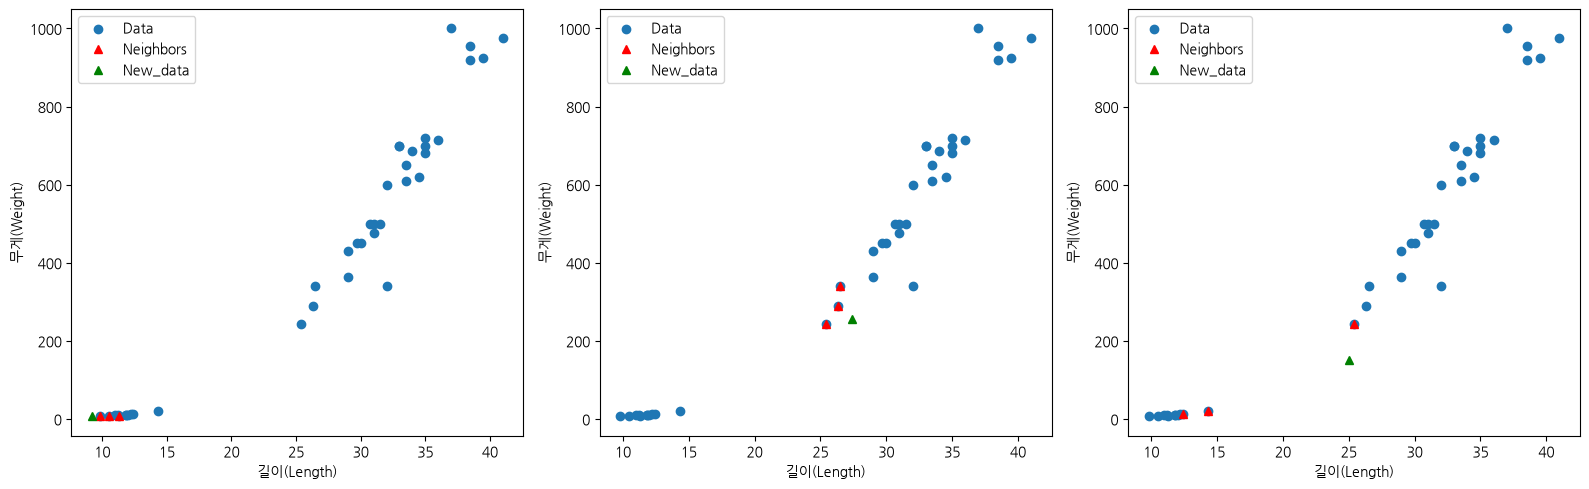

In [40]:
## --------------------------------------------------------------
## => 데이터와 최근접이웃데이터들 시각화
## => 2개의 데이터에 대한 이웃데이터 : 1행 2열 길이Length, 무게Weight
## --------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, idx in zip(axes, [0, 1, 2]):
    neighborSR   = x_train2.iloc[indices[idx]]
    dataSR       = new_data.iloc[idx]

    ax.scatter(x_train2['Length'], x_train2['Weight'], label='Data')

    ax.plot(neighborSR['Length'], neighborSR['Weight'], 'r^', label='Neighbors')
    
    ax.plot(dataSR['Length'], dataSR['Weight'], 'g^', label='New_data')
    ax.set_xlabel('길이(Length)')
    ax.set_ylabel('무게(Weight)')
    ax.legend()

plt.tight_layout()
plt.show()

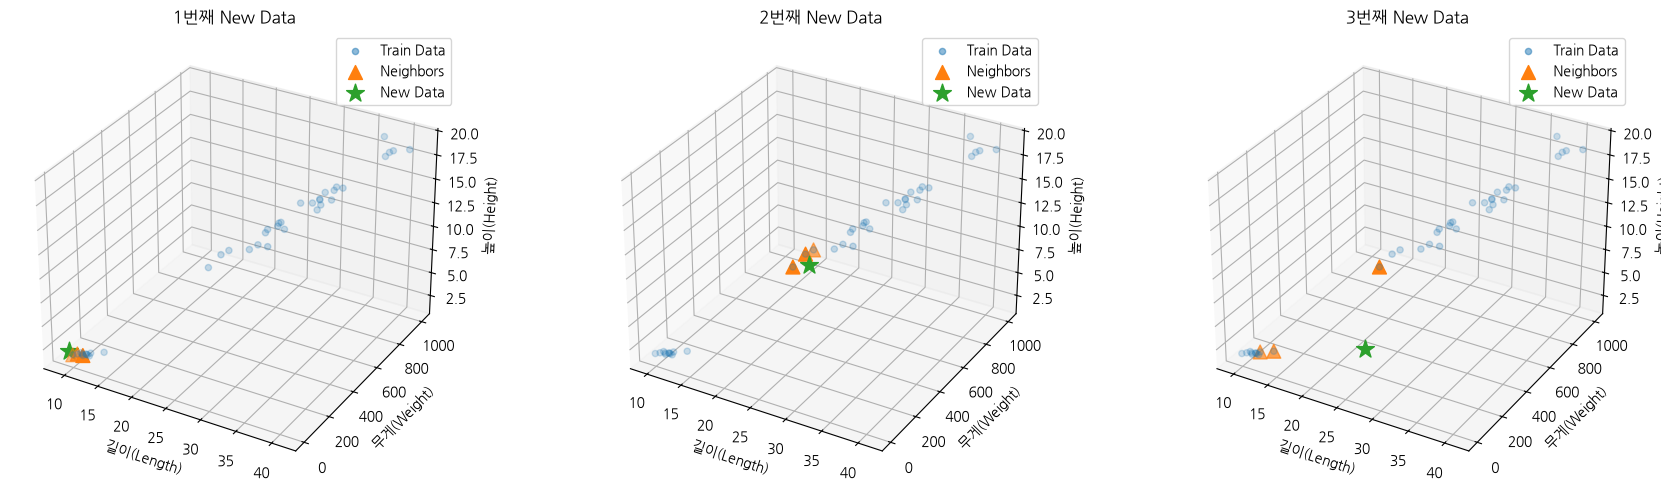

In [ ]:
## --------------------------------------------------------------
## => 데이터와 최근접이웃데이터들 시각화
## => 3개의 데이터에 대한 이웃데이터 : 1행 3열 길이Length, 무게Weight, 높이 Height
## --------------------------------------------------------------
fig = plt.figure(figsize=(18, 5))

for graph_idx, data_idx in enumerate([0, 1, 2], start=1):
    
    # 1행 3열 중 graph_idx 번째 위치에 3D 그래프 생성
    ax = fig.add_subplot(1, 3, graph_idx, projection='3d')
    
    # 해당 new_data의 최근접 이웃
    neighborSR = x_train2.iloc[indices[data_idx]]
    
    # 해당 new_data
    dataSR = new_data.iloc[data_idx]

    # 전체 학습 데이터
    ax.scatter( x_train2['Length'], x_train2['Weight'], x_train2['Height'], 
                label='Train Data', alpha=0.5 )

    # 최근접 이웃
    ax.scatter( neighborSR['Length'], neighborSR['Weight'], neighborSR['Height'], 
                marker='^',s=100,label='Neighbors')
    
    # 새 데이터
    ax.scatter( dataSR['Length'], dataSR['Weight'], dataSR['Height'], 
                marker='*',s=180,label='New Data')

    ax.set_title(f'{data_idx + 1}번째 New Data')
    ax.set_xlabel('길이(Length)')
    ax.set_ylabel('무게(Weight)')
    ax.set_zlabel('높이(Height)')
    ax.legend()

plt.tight_layout()
plt.show()